# Fish vs Non-Fish Doodle Classification using CNN
This project trains a CNN on Google's QuickDraw dataset to classify fish and non-fish doodles.

## Loading Dataset

Download and load doodle bitmaps from QuickDraw's public storage using NumPy.
Classes used:

- Fish (Positive Class)
- Cloud
- Cat
- Bird
- Leaf
- Airplane
- Speedboat (Negative Classes)

Samples :
- Fish: 5000 samples
- Non-Fish: 1000 samples from each negative category

In [1]:
import numpy as np
import requests
from io import BytesIO

# Public QuickDraw URL
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/fish.npy"
url2 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cloud.npy"
url3 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy"
url4 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/leaf.npy"
url5 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/bird.npy"
url6 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/speedboat.npy"
url7 = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/airplane.npy"

# Download the .npy file
fish_response = requests.get(url)
cloud_response = requests.get(url2)
cat_response = requests.get(url3)
leaf_response = requests.get(url4)
bird_response = requests.get(url5)
boat_response = requests.get(url6)
airplane_response = requests.get(url7)

# Load into NumPy array
fish_data = np.load(BytesIO(fish_response.content))
cloud_data = np.load(BytesIO(cloud_response.content))
cat_data = np.load(BytesIO(cat_response.content))
leaf_data = np.load(BytesIO(leaf_response.content))
bird_data = np.load(BytesIO(bird_response.content))
boat_data = np.load(BytesIO(boat_response.content))
airplane_data = np.load(BytesIO(airplane_response.content))

print("Dataset Shape:", fish_data.shape)

# Example: first doodle
fish_sample = fish_data[:10000]

cloud_sample = cloud_data[:3000]
cat_sample = cat_data[:3000]
leaf_sample = leaf_data[:3000]
bird_sample = bird_data[:3000]
boat_sample = boat_data[:3000]
airplane_sample = airplane_data[:3000]

nonfish_sample = np.concatenate([cloud_sample , cat_sample , leaf_sample , bird_sample , boat_sample , airplane_sample])

print("Single doodle shape:", fish_sample.shape)
print(nonfish_sample.shape)

# print(fish_sample[0])
# print(nonfish_sample[0])
# print(nonfish_sample[2005])



Dataset Shape: (134150, 784)
Single doodle shape: (10000, 784)
(18000, 784)


## Creating Labels

Binary classification labels:

- Fish → 1
- Non-Fish → 0

In [2]:
# Give labels : fish -> 1, nonfish -> 0

fish_labels = np.ones(len(fish_sample))
nonfish_labels = np.zeros(len(nonfish_sample))


In [3]:
# Combine doodles for fish and nonfish (this acts as features)
x = np.concatenate([fish_sample, nonfish_sample])

# Combine labels together (this acts as target)
y = np.concatenate([fish_labels, nonfish_labels])

print(x.shape)
print(y.shape)

(28000, 784)
(28000,)


In [4]:
# shuffle dataset for better training

indices = np.random.permutation(len(x))

x = x[indices]
y = y[indices]

# print(y)


In [5]:
# normalize the pixel values from (0..255 -> 0..1)
x = x / 255.0

print(x[0])


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [6]:
# reshape data from 784 -> 28 * 28 * 1
#  here 784 means that quickdraw dataset stored image vectors in the form of
#  a flattened 1d array
#  but cnn works well when given a grid form so we need to reshape it again
#  to 28 * 28 form

x = x.reshape(-1, 28, 28, 1)
print(x.shape)

(28000, 28, 28, 1)


In [7]:
# split data into training validation and testing

from sklearn.model_selection import train_test_split

# Step 1: Train and temporary split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42
)

# Step 2: Validation and test split
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(19600, 28, 28, 1)
(4200, 28, 28, 1)
(4200, 28, 28, 1)


## CNN Architecture

The network consists of:

1. Convolution Layer (32 filters)
2. Max Pooling Layer
3. Convolution Layer (64 filters)
4. Max Pooling Layer
5. Flatten Layer
6. Dense Layer (128 neurons)
7. Dropout Layer
8. Sigmoid Output Layer

The architecture is designed for binary image classification.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
print(tf.__version__)

2.20.0


In [9]:
model = Sequential()

# first convolution layer
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1)))

# pooling layer (from (28, 28) -> (14, 14))
model.add(MaxPooling2D((2,2)))

# second convolution layer
model.add(Conv2D(64, (3,3), activation="relu"))

# second pooling layer
model.add(MaxPooling2D((2,2)))

# flatten layer to give single input to the dense layer
model.add(Flatten())

# dense layer which decides whether a fish or not
# here 128 says that 128 neurons decide our answer , we can add 64, 128, 256 based on accuracy
model.add(Dense(128, activation = "relu"))

# dropoutlayer, as the name suggests, drop ut some of the neurons in participating to our answer
# here 50% ignored
model.add(Dropout(0.5))

# output layer
model.add(Dense(1, activation = "sigmoid"))

# now compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics = ["accuracy"])

# show result
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,873 (874.50 KB)

 Trainable params: 223,873 (874.50 KB)

 Non-trainable params: 0 (0.00 B)

## Training the CNN

The model is trained for 10 epochs using mini-batches of 32 images.

Validation accuracy is monitored after every epoch.

In [10]:
# train the model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=32)

Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8937 - loss: 0.2683 - val_accuracy: 0.9374 - val_loss: 0.1776
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9381 - loss: 0.1789 - val_accuracy: 0.9398 - val_loss: 0.1584
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9490 - loss: 0.1486 - val_accuracy: 0.9536 - val_loss: 0.1328
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9573 - loss: 0.1255 - val_accuracy: 0.9540 - val_loss: 0.1337
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9615 - loss: 0.1120 - val_accuracy: 0.9595 - val_loss: 0.1161
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9655 - loss: 0.0975 - val_accuracy: 0.9605 - val_loss: 0.1175
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9695 - loss: 0.0865 - val_accuracy: 0.9645 - val_loss: 0.1114
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9719 - loss: 0.0769 - 

In [11]:
# evaluate the model
model.evaluate(X_test, Y_test)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9612 - loss: 0.1208


[0.12082167714834213, 0.9611904621124268]

### Results

Test Accuracy: 96.12%

The classifier demonstrates strong generalization performance on unseen doodles.

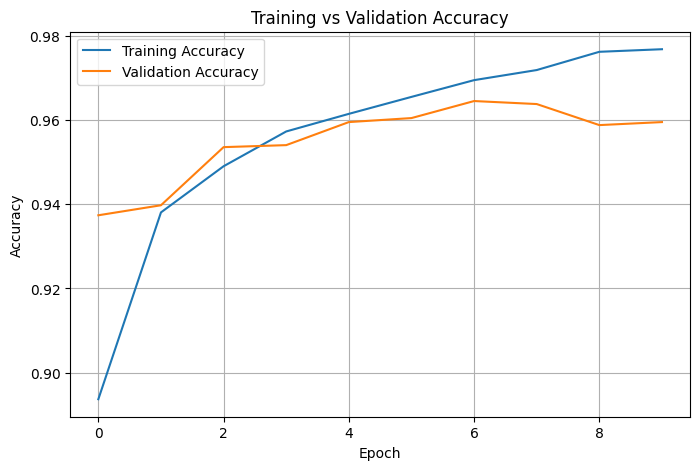

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## Testing with different samples

In [13]:
sample = fish_sample[20]

img = sample.reshape(28,28)
img = img / 255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
[[0.3167508]]


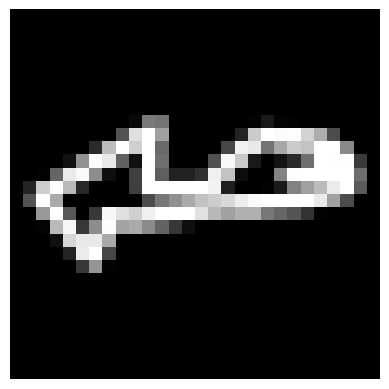

In [14]:
import matplotlib.pyplot as plt

plt.imshow(img[0,:,:,0], cmap='gray')
plt.axis('off')
plt.show()

In [15]:
sample2 = nonfish_sample[5000]
img2 = sample2.reshape(28,28)
img2 = img2 / 255.0
img2 = img2.reshape(1,28,28,1)

prediction2 = model.predict(img2)

print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.06625851]]


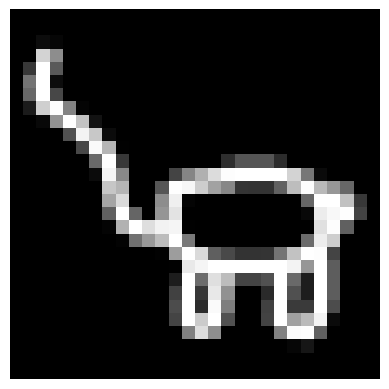

In [16]:
import matplotlib.pyplot as plt

plt.imshow(img2[0,:,:,0], cmap='gray')
plt.axis('off')
plt.show()

In [17]:
sample3 = fish_sample[0]

img3 = sample3.reshape(28,28)
img3 = img3 / 255.0
img3 = img3.reshape(1,28,28,1)

prediction3 = model.predict(img3)

print(prediction3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.9873178]]


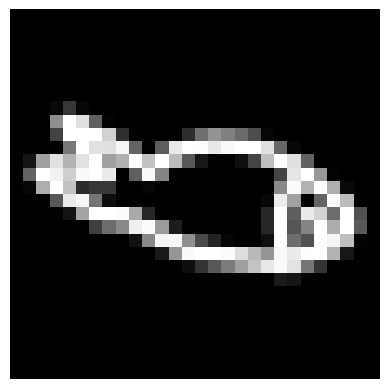

In [18]:
import matplotlib.pyplot as plt

plt.imshow(img3[0,:,:,0], cmap='gray')
plt.axis('off')
plt.show()

In [19]:
sample4 = nonfish_sample[0]
img4 = sample4.reshape(28,28)
img4 = img4 / 255.0
img4 = img4.reshape(1,28,28,1)

prediction4 = model.predict(img4)

print(prediction4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.01099517]]


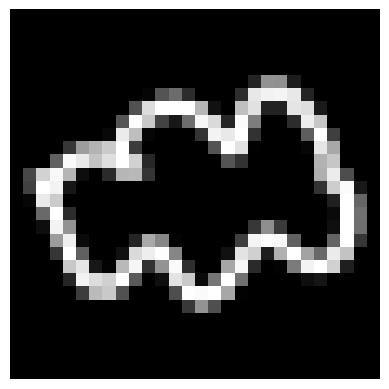

In [20]:
import matplotlib.pyplot as plt

plt.imshow(img4[0,:,:,0], cmap='gray')
plt.axis('off')
plt.show()

## Testing on Custom Fish Drawing

In [21]:
from PIL import Image

def preprocess_image(image_path):
    # Load image
    img = Image.open(image_path)

    # Convert to grayscale
    img = img.convert("L")

    # Convert to numpy array
    img_arr = np.array(img)

    # Detect non-white pixels (the drawing)
    mask = img_arr < 250

    # Find bounding box
    coords = np.argwhere(mask)

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Crop to drawing
    cropped = img_arr[y_min:y_max+1, x_min:x_max+1]

    # Add small padding
    padding = 10
    cropped = np.pad(
        cropped,
        pad_width=padding,
        mode='constant',
        constant_values=255
    )

    # Resize to 28x28
    resized = Image.fromarray(cropped).resize((28, 28))

    # Convert back to numpy
    final_img = np.array(resized)

    # Invert colors so doodle becomes bright
    final_img = 255 - final_img

    # Normalize
    final_img = final_img.astype("float32") / 255.0

    # Add channel dimension
    final_img = np.expand_dims(final_img, axis=-1)

    # Add batch dimension
    final_img = np.expand_dims(final_img, axis=0)

    return final_img

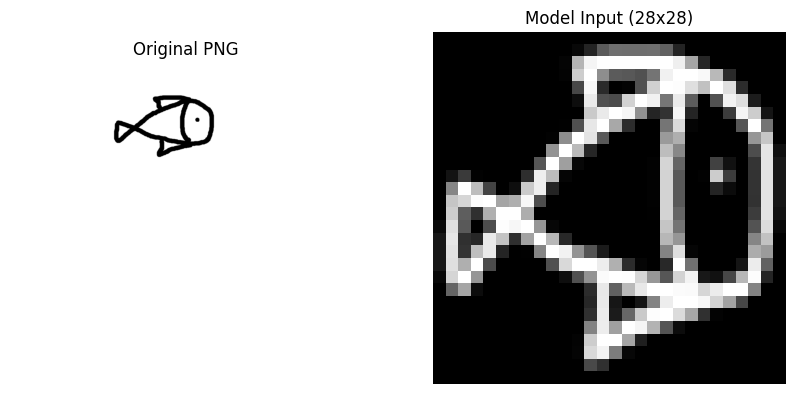

In [23]:
# visualize

# Original image
original = Image.open("fish2.png")

# Processed image
processed = preprocess_image("fish2.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original
axes[0].imshow(original)
axes[0].set_title("Original PNG")
axes[0].axis("off")

# Processed
axes[1].imshow(processed[0, :, : ,0], cmap="gray")
axes[1].set_title("Model Input (28x28)")
axes[1].axis("off")

plt.show()


In [24]:
result = model.predict(processed)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.9646391]]


### Prediction

Fish Probability: 0.9646

The model successfully recognizes a hand-drawn fish outside the original QuickDraw dataset.

## Model Persistence

The trained model is saved as a reusable Keras model for deployment in future applications.

In [25]:
model.save_weights("fish_weight.weights.h5")